На мою думку у даному випадку цей підхід виглядає не зовсім вдалим, тому що на графіку elbow спостерігається нестабільна поведінка — “лікоть” не є чітким і кожного разу може зміщуватись. Це означає, що дані погано формують виражені кластери. Водночас алгоритм все одно видає рекомендовану кількість кластерів, яку можна використовувати як орієнтовну для подальшого аналізу.

Using Colab cache for faster access to the 'regression-with-neural-networking' dataset.
['concrete_data.csv']
----------------------------------
   Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   Coarse Aggregate  Fine Aggregate  Age  Strength  
0            1040.0           676.0   28     79.99  
1            1055.0           676.0   28     61.89  
2             932.0           594.0  270     40.27  
3             932.0           594.0  365     41.05  
4             978.4           825.5  360     44.30  
----------------------------------
   Components
0           6
1           6
2           6
3           6
4           6
---------------

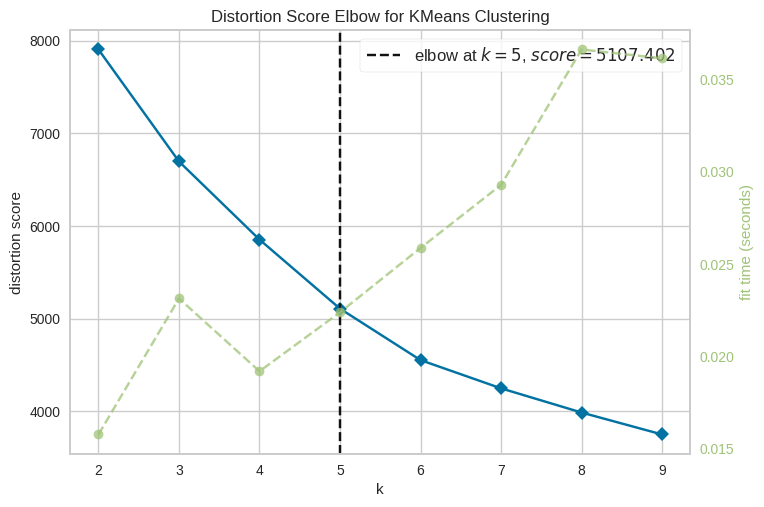

   Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   Coarse Aggregate  Fine Aggregate  Age  Strength  Components  Cluster  
0            1040.0           676.0   28     79.99           6        0  
1            1055.0           676.0   28     61.89           6        4  
2             932.0           594.0  270     40.27           6        2  
3             932.0           594.0  365     41.05           6        2  
4             978.4           825.5  360     44.30           6        2  
----------------------------------
         Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  \
Cluster                                      

In [11]:
import os
import kagglehub
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

#завантаження датасету
path = kagglehub.dataset_download("prathamtripathi/regression-with-neural-networking")

print(os.listdir(path))
print('----------------------------------')

#зчитування даних
concrete = pd.read_csv(path + "/concrete_data.csv")

print(concrete.head())
print('----------------------------------')

#створення нової ознаки
concrete['Components'] = (concrete.iloc[:, :-1] > 0).sum(axis=1)

print(concrete[['Components']].head())
print('----------------------------------')

#нормалізація
x = concrete.drop(columns=['Cluster'], errors='ignore')
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

#elbowmethod
model = KMeans(random_state= 42, n_init= 10)

visualizer = KElbowVisualizer(model, k= (2, 10))
visualizer.fit(x_scaled)
visualizer.show()

#кластеризація
kmeans = KMeans(n_clusters= 5, random_state= 42)
labels = kmeans.fit_predict(x_scaled)

concrete['Cluster'] = labels

print(concrete.head())
print('----------------------------------')

#звіт по кластерах
report = concrete.groupby('Cluster').median()
report['Count'] = concrete.groupby('Cluster').size()

print(report)
print('----------------------------------')